# Importing Libraries

In [41]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report

# Reading the Dataset

In [42]:
file_path = "/content/heart.csv"  # Change the path if it is different
df = pd.read_csv(file_path)

df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# Data Analysis

## Checking the Dataset

In [43]:
print(f"The data types for each column:\n{df.dtypes}")
print(f"\nThe shape of the dataset is: {df.shape}")
print(f"\nThe number of missing values in each column:\n{df.isnull().sum()}")

The data types for each column:
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

The shape of the dataset is: (918, 12)

The number of missing values in each column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


## Distribution of the Target Labels

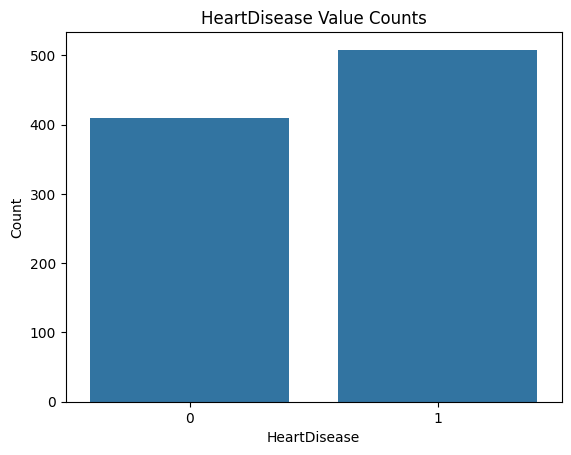

In [44]:
# Count plot of HeartDisease values
sns.countplot(x='HeartDisease', data=df)

plt.title('HeartDisease Value Counts')
plt.xlabel('HeartDisease')
plt.ylabel('Count')
plt.show()

# Encoding Categorical Features

In [45]:
categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"Shape after encoding: {df_encoded.shape}")
print(f"Current columns:\n{df_encoded.columns.tolist()}")

Shape after encoding: (918, 16)
Current columns:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


# Train-Test Splitting

In [46]:
feature_cols = [c for c in df_encoded.columns if c != 'HeartDisease']

X = df_encoded[feature_cols].astype(float)
y = df_encoded['HeartDisease'].astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape} | Testing set shape: {X_test.shape}")

Training set shape: (734, 15) | Testing set shape: (184, 15)


# Scaling the Columns

In [47]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

# Tasks Starts Here

## Weight Initialization

In [48]:
def init_weights(num_features, num_hidden_layer, random_seed=42):
    """
    Using Xavier initialization
    """

    random.seed(random_seed)

    W1 = [[random.gauss(0, (2.0 / num_features) ** 0.5) for _ in range(num_features)] for _ in range(num_hidden_layer)]
    b1 = [0.0] * num_hidden_layer

    W2 = [random.gauss(0, (2.0 / num_hidden_layer) ** 0.5) for _ in range(num_hidden_layer)]
    b2 = 0.0

    return W1, b1, W2, b2

## Implement the ReLU Function

In [58]:
def relu(z):
    # ------------ YOUR CODE STARTS HERE ------------
    pass
    # ------------ YOUR CODE ENDS HERE --------------

## Implement the Sigmoid Function

In [59]:
def sigmoid(z):
    # ------------ YOUR CODE STARTS HERE ------------
    pass
    # ------------ YOUR CODE ENDS HERE --------------

## Implement the Forward Propagation

In [51]:
def forward_prop_single(x, W1, b1, W2, b2):
    """
    Forward pass for a single sample from the dataset
    """

    num_hidden_layer = len(W1)
    num_features = len(x)

    # --- Layer 1: z1 = (W1^T)x + b1 ---
    z1 = []
    for j in range(num_hidden_layer):
        z = 0.0
        for k in range(num_features):
        # ------------ YOUR CODE STARTS HERE ------------
            pass

        z1.append(z)
        # ------------ YOUR CODE ENDS HERE --------------


    # --- Apply ReLU ---
    a1 = [relu(z) for z in z1]


    # --- Layer 2: z2 = (W2^T)a1 + b2 ---
    z2 = 0.0
    for j in range(num_hidden_layer):
    # ------------ YOUR CODE STARTS HERE ------------
        pass
    # ------------ YOUR CODE ENDS HERE --------------


    # --- Apply Sigmoid ---
    y_hat = sigmoid(z2)

    return z1, a1, z2, y_hat



def forward_prop(X, W1, b1, W2, b2):
    """
    Returns the predicted probabilities for all the samples in the dataset
    """
    return [forward_prop_single(X[i], W1, b1, W2, b2)[-1] for i in range(len(X))]

## Implementing the Binary Cross-Entropy Loss

In [60]:
def bce_loss(X, y, W1, b1, W2, b2):
    m = len(y)
    total_loss = 0.0

    for i in range(m):
        _, _, _, y_hat = forward_prop_single(X[i], W1, b1, W2, b2)

        # Numerical clipping to avoid log(0)
        p = max(1e-15, min(1 - 1e-15, y_hat))

        # Calculate BCE loss for sample i and accumulate it in total_loss
        # ------------ YOUR CODE STARTS HERE ------------
        pass
        # ------------ YOUR CODE ENDS HERE --------------

    return total_loss / m

## Implement Backpropagation

In [61]:
def backprop(X, y, W1, b1, W2, b2):
    m = len(y)
    num_hidden_layer = len(W1)
    num_features = len(X[0])

    # Initialize gradients
    dW1 = [[0.0] * num_features for _ in range(num_hidden_layer)]
    db1 = [0.0] * num_hidden_layer
    dW2 = [0.0] * num_hidden_layer
    db2 = 0.0

    for i in range(m):
        z1, a1, z2, y_hat = forward_prop_single(X[i], W1, b1, W2, b2)

        # Calculate dW2 and db2
        # ------------ YOUR CODE STARTS HERE ------------
        pass
        # ------------ YOUR CODE ENDS HERE --------------

        # Calculate dW1 and db1
        # ------------ YOUR CODE STARTS HERE ------------
        pass
        # ------------ YOUR CODE ENDS HERE --------------

    # Average over all samples
    for j in range(num_hidden_layer):
        for k in range(num_features):
            dW1[j][k] /= m
        db1[j] /= m
        dW2[j] /= m
    db2 /= m

    return dW1, db1, dW2, db2

## Weight Update

In [62]:
def weight_update(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate=0.05):
    num_hidden_layer = len(W1)
    num_features = len(W1[0])

    for j in range(num_hidden_layer):
        for k in range(num_features):
            W1[j][k] -= learning_rate * dW1[j][k]
        b1[j] -= learning_rate * db1[j]
        W2[j] -= learning_rate * dW2[j]
    b2 -= learning_rate * db2

    return W1, b1, W2, b2

## Calculate Accuracy

In [63]:
def predict_class(X, W1, b1, W2, b2, threshold=0.5):
    return [1 if p >= threshold else 0 for p in forward_prop(X, W1, b1, W2, b2)]

def calculate_accuracy(X, y, W1, b1, W2, b2):
    y_pred = predict_class(X, W1, b1, W2, b2)

    return sum(1 for i in range(len(y)) if y_pred[i] == int(y[i])) / len(y)

## Training Loop

In [64]:
def train_nn(X_train, y_train, X_test, y_test, num_hidden_layer=16, learning_rate=0.05, epochs=300, random_seed=42):
    """
    Train a two-layer neural network with gradient descent.

    Returns
    -------
    params       : final (W1, b1, W2, b2)
    train_losses, test_losses   : BCE per epoch
    train_accs,   test_accs     : accuracy per epoch
    """
    num_features = len(X_train[0])
    W1, b1, W2, b2 = init_weights(num_features, num_hidden_layer, random_seed=42)

    train_losses, test_losses = [], []
    train_accs, test_accs = [], []

    for epoch in range(epochs):
        # Forward + backward
        dW1, db1, dW2, db2 = backprop(X_train, y_train, W1, b1, W2, b2)
        W1, b1, W2, b2 = weight_update(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate)

        # Record metrics
        tr_loss = bce_loss(X_train, y_train, W1, b1, W2, b2)
        te_loss = bce_loss(X_test,  y_test,  W1, b1, W2, b2)
        tr_acc  = calculate_accuracy(X_train, y_train, W1, b1, W2, b2)
        te_acc  = calculate_accuracy(X_test,  y_test,  W1, b1, W2, b2)

        train_losses.append(tr_loss)
        test_losses.append(te_loss)
        train_accs.append(tr_acc)
        test_accs.append(te_acc)

        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1:4d} | "
                  f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
                  f"Test Loss: {te_loss:.4f}  Acc: {te_acc:.4f}")

    return (W1, b1, W2, b2), train_losses, test_losses, train_accs, test_accs

# Complete the Tasks

## Task 1

## Task 2

## Task 3